In [11]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"

model_names = ["RW", "DNS", "Ridge", "XGBoost"]

model_preds = {}
model_actuals = {}
model_metrics = {}

for name in model_names:
    path = MODEL_DIR / f"{name}.pkl"
    with open(path, "rb") as f:
        bundle = pickle.load(f)

    print(f"Loaded {name} from {path}, keys: {list(bundle.keys())}")

    model_preds[name]   = bundle["predictions"]
    model_actuals[name] = bundle["actuals"]
    model_metrics[name] = bundle["metrics"]   # <--- NEW

print("Models loaded:", list(model_preds.keys()))




Loaded RW from /Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/models/RW.pkl, keys: ['predictions', 'actuals', 'metrics']
Loaded DNS from /Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/models/DNS.pkl, keys: ['predictions', 'actuals', 'metrics']
Loaded Ridge from /Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/models/Ridge.pkl, keys: ['predictions', 'actuals', 'metrics', 'hyperparameters']
Loaded XGBoost from /Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/models/XGBoost.pkl, keys: ['predictions', 'actuals', 'metrics', 'hyperparameters']
Models loaded: ['RW', 'DNS', 'Ridge', 'XGBoost']


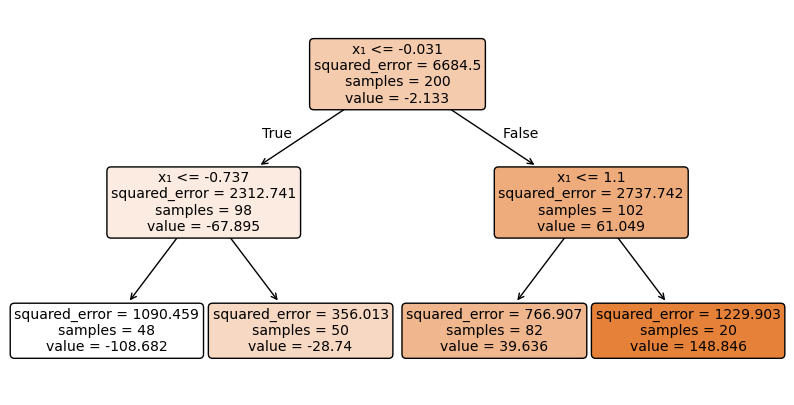

In [2]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# Generate small synthetic regression dataset
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# Fit a shallow regression tree (max depth = 2)
tree = DecisionTreeRegressor(max_depth=2, random_state=42)
tree.fit(X, y)

# Plot decision tree
plt.figure(figsize=(10, 5))
plot_tree(
    tree,
    filled=True,
    feature_names=["x₁"],
    impurity=True,
    precision=3,
    rounded=True,
)
plt.axis("off")  # remove border/heading axes
plt.show()


# Create Visualizations (All models in one plot, one subplot per model,  full yield curve)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Helper: get canonical actual series for a given (maturity, horizon)
# We use RW's actuals as canonical (they're aligned with others).
# -------------------------------------------------------------------
def get_actual_series(maturity, horizon):
    key = (maturity, horizon)
    if "RW" not in model_actuals:
        # fallback: take first model that has this key
        for m in model_actuals:
            if key in model_actuals[m]:
                return model_actuals[m][key]
        raise KeyError(f"No actual series found for {key}")
    return model_actuals["RW"][key]


# ================================================================
# FIGURE 1:
# All models vs Actual in one plot
# ================================================================
def plot_all_models_vs_actual(
    maturity="DGS10",
    horizon=10,
    N=200,
    models=("RW", "DNS", "Ridge", "XGBoost")
):
    """
    Plot Actual vs multiple models for a given maturity & horizon,
    using the last N common observations.
    """
    key = (maturity, horizon)
    actual = get_actual_series(maturity, horizon).rename("Actual")

    # Collect model predictions and align
    series_dict = {"Actual": actual}
    for model in models:
        pred_dict = model_preds.get(model, {})
        if key not in pred_dict:
            print(f"[WARN] {model} has no predictions for {key}, skipping.")
            continue
        series_dict[model] = pred_dict[key].rename(model)

    df = pd.concat(series_dict.values(), axis=1, join="inner").dropna()
    if df.empty:
        raise ValueError(f"No common dates for {key} across selected models.")

    # Keep last N observations
    df = df.iloc[-N:]

    plt.figure(figsize=(12, 5))
    for col in df.columns:
        if col == "Actual":
            plt.plot(df.index, df[col], label=col, linewidth=1.8)
        else:
            plt.plot(df.index, df[col], label=col, linestyle="--", linewidth=1.0)

    plt.title(f"{maturity} | h = {horizon} days – Actual vs Models")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURE 2:
# One subplot per model vs Actual
# ================================================================
def plot_models_vs_actual_subplots(
    maturity="DGS2",
    horizon=5,
    N=200,
    models=("RW", "DNS", "Ridge", "XGBoost")
):
    """
    Create a 1×K subplot figure: for each model, show Actual vs that model.
    """
    key = (maturity, horizon)
    actual = get_actual_series(maturity, horizon).rename("Actual")

    # Filter models that actually have predictions
    valid_models = []
    for model in models:
        pred_dict = model_preds.get(model, {})
        if key in pred_dict:
            valid_models.append(model)
        else:
            print(f"[WARN] {model} has no predictions for {key}, skipping.")

    if not valid_models:
        raise ValueError(f"No models with predictions for {key}.")

    n_models = len(valid_models)
    fig, axes = plt.subplots(
        nrows=1,
        ncols=n_models,
        figsize=(4 * n_models, 4),
        sharex=True,
        sharey=True
    )

    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, valid_models):
        pred_s = model_preds[model][key].rename(model)

        df = pd.concat([actual, pred_s], axis=1, join="inner").dropna()
        if df.empty:
            ax.set_title(f"{model} (no common data)")
            continue

        df = df.iloc[-N:]

        ax.plot(df.index, df["Actual"], label="Actual", linewidth=1.5)
        ax.plot(df.index, df[model], label=model, linestyle="--", linewidth=1.0)

        ax.set_title(f"{model}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    axes[0].set_ylabel("Yield (%)")
    axes[0].legend(loc="upper left")
    fig.suptitle(f"{maturity} | h = {horizon} days – Actual vs each model", y=1.02)
    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURE 3:
# Yield curve shape comparison (2y, 5y, 10y) at a given horizon & date
# ================================================================
def plot_yield_curve_comparison(
    horizon=10,
    eval_date=None,
    maturities=("DGS2", "DGS5", "DGS10"),
    models=("RW", "DNS", "Ridge", "XGBoost"),
):
    """
    Plot cross-sectional yield curve at a given horizon h for:
    - actual yields
    - each model's forecast

    Uses only dates that are common to:
    - the chosen actual series (taken from RW.actuals here)
    - every model's prediction series for all chosen maturities.
    """

    # ---------- 1) Collect all date sets ----------
    date_sets = []
    actual_series = {}

    # We'll use RW actual series as canonical (after your RW fix, indices are forecast dates)
    for mat in maturities:
        key = (mat, horizon)
        s_act = model_actuals["RW"].get(key)
        if s_act is None or len(s_act) == 0:
            raise ValueError(f"No actual series for {mat}, h={horizon} in RW.")
        actual_series[mat] = s_act
        date_sets.append(set(s_act.index))

    # Prediction dates for each model & maturity
    for model in models:
        pred_dict = model_preds.get(model, {})
        for mat in maturities:
            key = (mat, horizon)
            s_pred = pred_dict.get(key)
            if s_pred is None or len(s_pred) == 0:
                raise ValueError(f"No predictions for {model}, {mat}, h={horizon}.")
            date_sets.append(set(s_pred.index))

    # ---------- 2) Intersection of all date sets ----------
    common = sorted(set.intersection(*date_sets))
    if not common:
        raise ValueError(f"No common forecast dates found for h={horizon}.")

    # ---------- 3) Choose / validate eval_date ----------
    if eval_date is None:
        # use last common date by default
        eval_date = common[-1]
    else:
        eval_date = pd.Timestamp(eval_date)
        if eval_date not in common:
            raise ValueError(
                f"Chosen eval_date {eval_date.date()} not in common forecast dates.\n"
                f"Common range is {common[0].date()} .. {common[-1].date()}."
            )

    # ---------- 4) Build curves at that date ----------
    # x-axis = maturity in years
    mat_years = np.array([2, 5, 10])
    if len(maturities) == 3:
        mat_years = np.array([2, 5, 10])
    else:
        # crude mapping if you ever change maturities
        mat_years = np.arange(len(maturities)) + 1

    # Actual curve
    y_actual = np.array([actual_series[m].loc[eval_date] for m in maturities])

    # Model curves
    model_curves = {}
    for model in models:
        preds = model_preds[model]
        ys = []
        for m in maturities:
            key = (m, horizon)
            ys.append(preds[key].loc[eval_date])
        model_curves[model] = np.array(ys)

    # ---------- 5) Plot ----------
    plt.figure(figsize=(8, 5))
    plt.plot(mat_years, y_actual, marker="o", linewidth=2.0, label="Actual")

    for model, curve in model_curves.items():
        plt.plot(mat_years, curve, marker="o", linestyle="--", linewidth=1.2, label=model)

    plt.title(f"Yield Curve Comparison on {eval_date.date()} (h = {horizon})")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Plotted yield curve for {eval_date.date()}, horizon h={horizon}.")


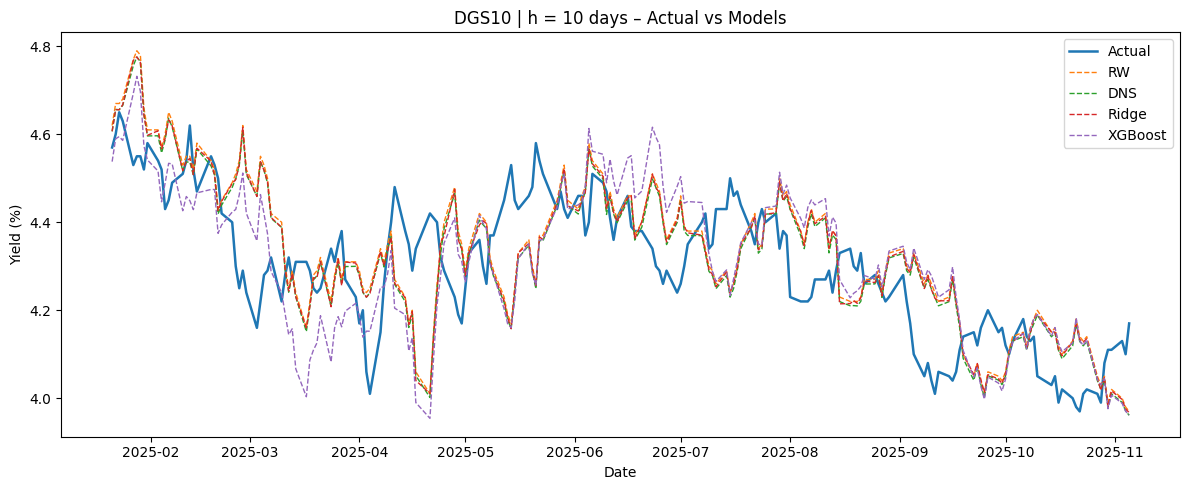

In [27]:
# 1) All models vs actual, e.g. DGS10, h=10, last 200 obs
plot_all_models_vs_actual(maturity="DGS10", horizon=10, N=200)


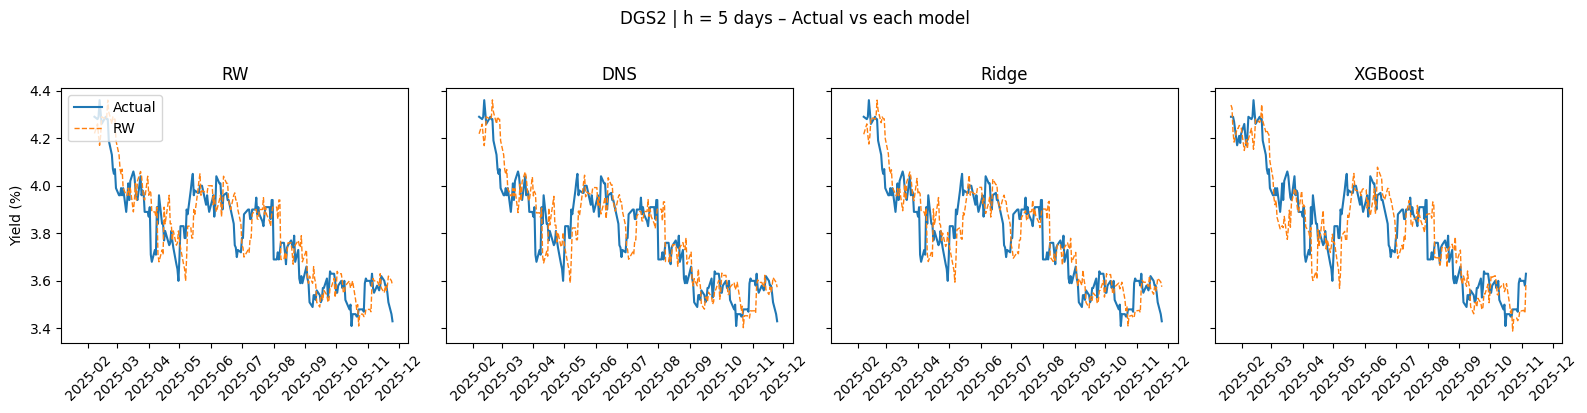

In [25]:
# 2) One subplot per model, e.g. DGS2, h=5
plot_models_vs_actual_subplots(maturity="DGS2", horizon=5, N=200)

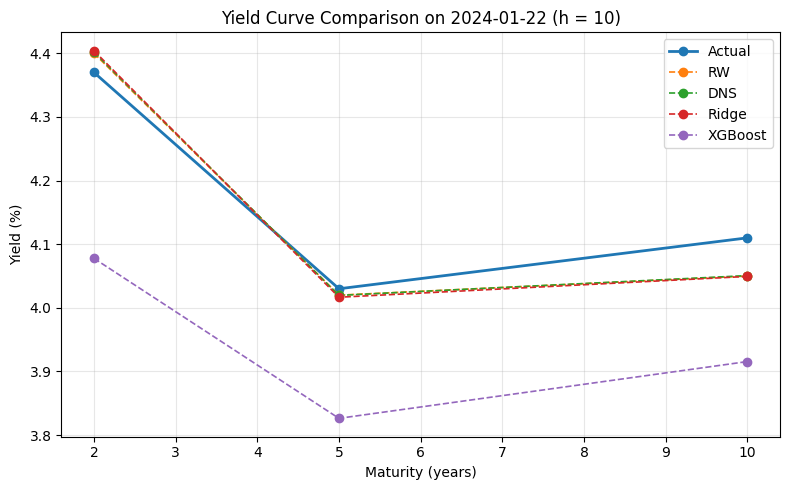

Plotted yield curve for 2024-01-22, horizon h=10.


In [71]:
# Or explicitly pick a date (must be a forecast date available in the series)
plot_yield_curve_comparison(horizon=10, eval_date="2024-01-22")

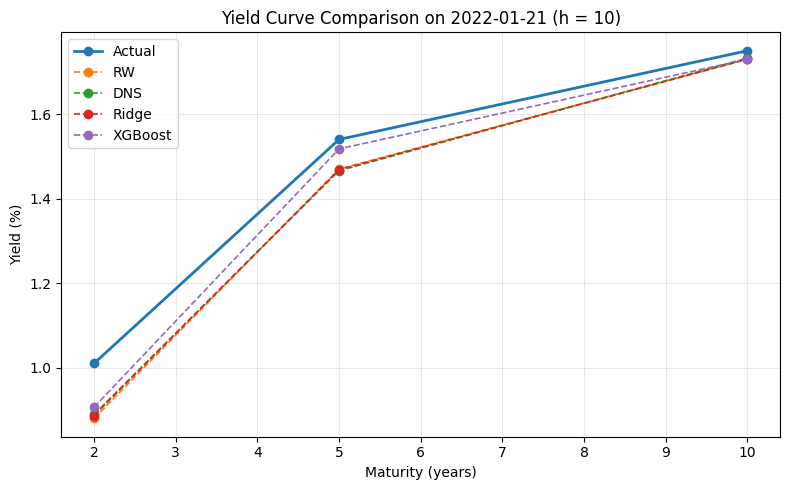

Plotted yield curve for 2022-01-21, horizon h=10.


In [73]:
plot_yield_curve_comparison(horizon=10, eval_date="2022-01-21")

In [69]:
def plot_models_vs_actual_for_2024(maturity="DGS10", horizon=10):
    """
    Plots Actual vs RW, DNS, Ridge, XGBoost forecasts for the full year 2024.
    """

    import matplotlib.pyplot as plt
    import pandas as pd

    start = "2024-01-01"
    end   = "2024-12-31"

    # Collect the series
    actual = model_actuals["RW"].get((maturity, horizon))   # actual is the same for all
    rw     = model_preds["RW"].get((maturity, horizon))
    dns    = model_preds["DNS"].get((maturity, horizon))
    ridge  = model_preds["Ridge"].get((maturity, horizon))
    xgb    = model_preds["XGBoost"].get((maturity, horizon))

    if actual is None:
        raise ValueError("No actual series for given maturity/horizon.")

    # Restrict to 2024
    actual_2024 = actual.loc[start:end]

    def slice_if_exists(s):
        return s.loc[start:end] if s is not None else None

    rw_2024    = slice_if_exists(rw)
    dns_2024   = slice_if_exists(dns)
    ridge_2024 = slice_if_exists(ridge)
    xgb_2024   = slice_if_exists(xgb)

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(actual_2024.index, actual_2024.values, label="Actual", linewidth=2)

    if rw_2024 is not None:
        plt.plot(rw_2024.index, rw_2024.values, "--", label="RW", linewidth=1.3)
    if dns_2024 is not None:
        plt.plot(dns_2024.index, dns_2024.values, "--", label="DNS", linewidth=1.3)
    if ridge_2024 is not None:
        plt.plot(ridge_2024.index, ridge_2024.values, "--", label="Ridge", linewidth=1.3)
    if xgb_2024 is not None:
        plt.plot(xgb_2024.index, xgb_2024.values, "--", label="XGBoost", linewidth=1.3)

    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Yield (%)", fontsize=12)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


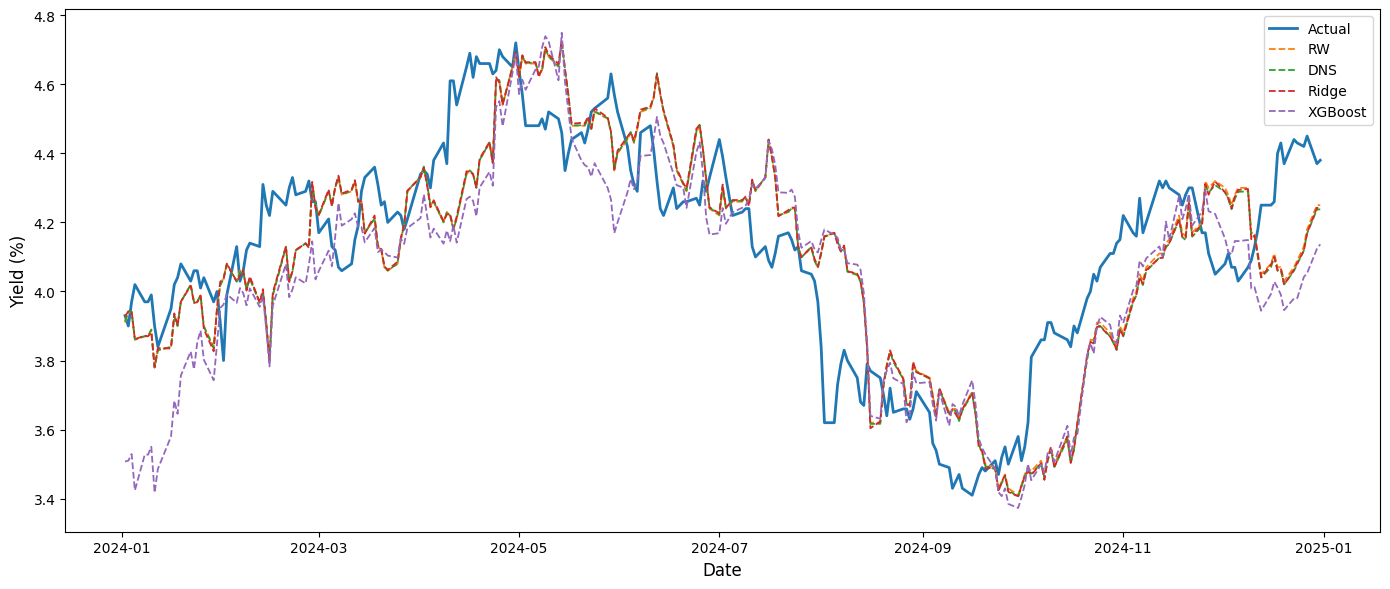

In [70]:
plot_models_vs_actual_for_2024("DGS5", horizon=10)


In [74]:
import pandas as pd

# Models and maturities we care about
models      = ["RW", "DNS", "Ridge", "XGBoost"]
maturities  = ["DGS2", "DGS5", "DGS10"]
horizons    = [1, 5, 10, 30]   # optional, for ordering

rmse_tables = {}

for mat in maturities:
    cols = {}

    for model in models:
        metrics_df = model_metrics[model]   # MultiIndex (Maturity, Horizon)

        # Extract RMSE for this maturity across all horizons
        # -> Series indexed by Horizon
        rmse_series = (
            metrics_df
            .loc[(mat, slice(None)), "RMSE"]
        )

        # Drop to just Horizon index
        rmse_series.index = rmse_series.index.get_level_values("Horizon")

        # Optionally reindex to specific order of horizons
        rmse_series = rmse_series.reindex(horizons)

        cols[model] = rmse_series

    # Build table: index = Horizon, columns = models
    table = pd.DataFrame(cols)
    table.index.name = "Horizon"

    # Optional rounding for display (you can skip if you prefer raw values)
    rmse_tables[mat] = table.round(6)

# ---- Show the three tables ----
print("RMSE table for DGS2:")
display(rmse_tables["DGS2"])

print("\nRMSE table for DGS5:")
display(rmse_tables["DGS5"])

print("\nRMSE table for DGS10:")
display(rmse_tables["DGS10"])


RMSE table for DGS2:


,RW,DNS,Ridge,XGBoost
Horizon,,,,
1,0.061234,0.061312,0.061421,0.065850
5,0.131264,0.131994,0.132197,0.144119
10,0.188553,0.190579,0.190964,0.210959
30,0.357070,0.366263,0.369247,0.413400



RMSE table for DGS5:


,RW,DNS,Ridge,XGBoost
Horizon,,,,
1,0.062582,0.062685,0.062806,0.065312
5,0.134244,0.135193,0.135146,0.141190
10,0.189948,0.192971,0.193134,0.206624
30,0.348277,0.361938,0.364119,0.414612



RMSE table for DGS10:


,RW,DNS,Ridge,XGBoost
Horizon,,,,
1,0.058991,0.059081,0.059137,0.061816
5,0.126820,0.127669,0.127458,0.136784
10,0.179106,0.181670,0.181782,0.193798
30,0.326972,0.338187,0.346037,0.388307
